In [14]:
!pip install -U scikit-learn scikeras

!pip install scikeras

import sklearn
import scikeras

print("scikit-learn version:", sklearn.__version__)
print("scikeras version:", scikeras.__version__)
#scikit-learn >= 1.2.0
#scikeras >= 0.10.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 29.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
    return func(self, options, args)
           ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/commands/install.py", line 447, in run
^C
scikit-learn version: 1.6.1
scikeras version: 0.13.0


In [1]:
# =============================================================================
# LSTM WIND SPEED FORECASTING WITH HYPERPARAMETER OPTIMIZATION
# =============================================================================
# This script implements Long Short-Term Memory (LSTM) networks for wind
# speed forecasting using lag features, with four approaches:
# Original (manual), Grid Search CV, Randomized Search CV, and Optuna.
# =============================================================================

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 1: PACKAGE INSTALLATION
# ─────────────────────────────────────────────────────────────────────────────

! pip install optuna
#! pip install scikeras
! pip install xgboost

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 2: IMPORT LIBRARIES
# ─────────────────────────────────────────────────────────────────────────────

# Standard libraries
import random
import warnings
warnings.filterwarnings("ignore")

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objs as go

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    TimeSeriesSplit
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score
)
from scipy.stats import randint, uniform

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# SciKeras wrapper (enables sklearn API for Keras)
from scikeras.wrappers import KerasRegressor

# Optuna for Bayesian optimisation
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # Suppress verbose output

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 3: REPRODUCIBILITY SEEDS
# ─────────────────────────────────────────────────────────────────────────────

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [4]:
 #─────────────────────────────────────────────────────────────────────────────
# SECTION 4: LOAD DATASET
# ─────────────────────────────────────────────────────────────────────────────

# Dataset source (Google Sheets exported as CSV):
# https://docs.google.com/spreadsheets/d/1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC

sheet_id   = "1j_Euo80PrGckVDVr2hTG9zZebxJD0TSC"
sheet_name = "Sheet1"
csv_url    = (
    f"https://docs.google.com/spreadsheets/d/{sheet_id}"
    f"/gviz/tq?tqx=out:csv&sheet={sheet_name}"
)

# Read the Google Sheet as CSV
df = pd.read_csv(csv_url)

# Backup original DataFrame before any modifications
df_backup = df.copy()

# Set Date as the index
df = df.set_index('Date')

# Drop calendar columns (YEAR, MO, DY) — not needed as model features
df = df.drop(columns=["YEAR", "MO", "DY"])

print("Dataset loaded. Shape:", df.shape)
print(df.head())

Dataset loaded. Shape: (4017, 14)
                      PREC  SURF_PRESSSURE  MAX_TEMP  MIN_TEMP     RH  \
Date                                                                    
2013-01-01 00:00:00   0.22           99.57     28.16     23.90  85.13   
2013-01-02 00:00:00   1.09           99.65     27.65     23.41  86.19   
2013-01-03 00:00:00  13.42           99.68     28.38     23.42  86.26   
2013-01-04 00:00:00   8.79           99.65     27.58     22.93  86.31   
2013-01-05 00:00:00   2.60           99.50     26.16     22.17  86.88   

                     AVG_TEMP  SL_PRESSURE  CLOUD_COVER  WS10M    WD_sin  \
Date                                                                       
2013-01-01 00:00:00      28.5       1009.2          5.0   3.99  0.600420   
2013-01-02 00:00:00      27.6       1010.4          5.0   4.25  0.500000   
2013-01-03 00:00:00      26.4       1011.0          8.0   4.75  0.439939   
2013-01-04 00:00:00      25.1       1010.1          8.0   5.74  0.424199  

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 5: FEATURE ENGINEERING — LAG FEATURES
# ─────────────────────────────────────────────────────────────────────────────

def create_lag_features(data, lags=3):
    """
    Create lag features for the time series data.

    Parameters:
        data : DataFrame containing the 'WS10M' column
        lags : int, number of lag periods to create

    Returns:
        lagged_data : DataFrame with original column plus lag columns
    """
    lagged_data = data.copy()  # Copy original data

    # Create lags and shift the series
    for lag in range(1, lags + 1):
        lagged_data[f'lag_{lag}'] = lagged_data['WS10M'].shift(lag)

    lagged_data.dropna(inplace=True)  # Drop rows with NaN values (due to shifting)
    return lagged_data


# Create lag features (3 lags) for WS10M only
df_lagged = create_lag_features(df[['WS10M']], lags=3)

print("\nLagged DataFrame (first 5 rows):")
print(df_lagged.head())




Lagged DataFrame (first 5 rows):
                     WS10M  lag_1  lag_2  lag_3
Date                                           
2013-01-04 00:00:00   5.74   4.75   4.25   3.99
2013-01-05 00:00:00   5.79   5.74   4.75   4.25
2013-01-06 00:00:00   4.52   5.79   5.74   4.75
2013-01-07 00:00:00   4.66   4.52   5.79   5.74
2013-01-08 00:00:00   3.61   4.66   4.52   5.79


In [6]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 6: TRAIN-TEST SPLIT (chronological, no shuffling)
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: For time series forecasting, data must be split chronologically
# to avoid data leakage (future data must never influence past predictions).

train_size = int(len(df_lagged) * 0.8)   # 70% for training
test_size  = len(df_lagged) - train_size  # Remaining 30% for testing

train = df_lagged.iloc[:train_size]       # Training set
test  = df_lagged.iloc[train_size:]       # Test set

print(f"\nTraining set size: {len(train)}")
print(f"Test set size:     {len(test)}")

print("\nTraining Data (first 5 rows):")
print(train.head())
print("\nTest Data (first 5 rows):")
print(test.head())




Training set size: 2809
Test set size:     1205

Training Data (first 5 rows):
                     WS10M  lag_1  lag_2  lag_3
Date                                           
2013-01-04 00:00:00   5.74   4.75   4.25   3.99
2013-01-05 00:00:00   5.79   5.74   4.75   4.25
2013-01-06 00:00:00   4.52   5.79   5.74   4.75
2013-01-07 00:00:00   4.66   4.52   5.79   5.74
2013-01-08 00:00:00   3.61   4.66   4.52   5.79

Test Data (first 5 rows):
                     WS10M  lag_1  lag_2  lag_3
Date                                           
2020-09-13 00:00:00   4.80   5.09   6.37   5.83
2020-09-14 00:00:00   4.70   4.80   5.09   6.37
2020-09-15 00:00:00   5.35   4.70   4.80   5.09
2020-09-16 00:00:00   4.99   5.35   4.70   4.80
2020-09-17 00:00:00   5.70   4.99   5.35   4.70


In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 7: VISUALISE TRAIN / TEST SPLIT
# ─────────────────────────────────────────────────────────────────────────────

# Create traces for each dataset
trace_train = go.Scatter(
    x=train.index, y=train['WS10M'],
    mode='lines', name='Training Set', line=dict(color='blue')
)
trace_test = go.Scatter(
    x=test.index, y=test['WS10M'],
    mode='lines', name='Test Set', line=dict(color='orange')
)

# Create vertical lines marking train/test date boundaries
line_train_min = go.Scatter(
    x=[train.index.min(), train.index.min()],
    y=[train['WS10M'].min(), train['WS10M'].max()],
    mode='lines', name='Train Start', line=dict(color='red', dash='dash')
)
line_train_max = go.Scatter(
    x=[train.index.max(), train.index.max()],
    y=[train['WS10M'].min(), train['WS10M'].max()],
    mode='lines', name='Train End', line=dict(color='red', dash='dash')
)
line_test_min = go.Scatter(
    x=[test.index.min(), test.index.min()],
    y=[test['WS10M'].min(), test['WS10M'].max()],
    mode='lines', name='Test Start', line=dict(color='green', dash='dash')
)
line_test_max = go.Scatter(
    x=[test.index.max(), test.index.max()],
    y=[test['WS10M'].min(), test['WS10M'].max()],
    mode='lines', name='Test End', line=dict(color='green', dash='dash')
)

layout = go.Layout(
    title='Training and Test Set with Date Ranges',
    xaxis=dict(title='Date'),
    yaxis=dict(title='Wind Speed (WS10M)'),
    legend=dict(title='Data Set'),
)

fig_split = go.Figure(
    data=[trace_train, trace_test,
          line_train_min, line_train_max,
          line_test_min,  line_test_max],
    layout=layout
)
fig_split.show()

print(f"\nTraining Set Date Range: Min = {train.index.min()}, Max = {train.index.max()}")
print(f"Test Set Date Range:     Min = {test.index.min()},  Max = {test.index.max()}")


Training Set Date Range: Min = 2013-01-04 00:00:00, Max = 2020-09-12 00:00:00
Test Set Date Range:     Min = 2020-09-13 00:00:00,  Max = 2023-12-31 00:00:00


In [8]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 8: PREPARE X / y ARRAYS
# ─────────────────────────────────────────────────────────────────────────────

# Prepare input features and target variable for model training
X_train = train.drop(columns=['WS10M'])   # Features: lag_1, lag_2, lag_3
y_train = train['WS10M']                  # Target: current wind speed

X_test  = test.drop(columns=['WS10M'])    # Features for testing
y_test  = test['WS10M']                   # Actual target values for testing

# Full dataset feature/target arrays (for reference)
X = df_lagged.drop(columns=['WS10M'])
y = df_lagged['WS10M']

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape)
print("y_test shape: ", y_test.shape)




X_train shape: (2809, 3)
y_train shape: (2809,)
X_test shape:  (1205, 3)
y_test shape:  (1205,)


In [9]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 9: HELPER FUNCTION — PERFORMANCE METRICS
# ─────────────────────────────────────────────────────────────────────────────

def evaluate_model(y_true, y_pred, model_name):
    """
    Calculate and print regression performance metrics.

    Parameters:
        y_true     : array-like, actual values
        y_pred     : array-like, predicted values
        model_name : str, label for the model/dataset

    Returns:
        mse, rmse, mae, mape, r2
    """
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100   # Manual MAPE (%)
    r2   = r2_score(y_true, y_pred)

    print(f"\n{model_name} Evaluation:")
    print(f"  MSE        : {mse:.4f}")
    print(f"  RMSE       : {rmse:.4f}")
    print(f"  MAE        : {mae:.4f}")
    print(f"  MAPE       : {mape:.2f}%")
    print(f"  R-squared  : {r2:.4f}")

    return mse, rmse, mae, mape, r2

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 10: PREPROCESSING — MIN-MAX SCALING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: The scaler is fit ONLY on the training set and then applied to the
# test set. Fitting on the full dataset before splitting would cause data
# leakage, as the test set statistics would influence the training transform.

# Scale features (X)
scaler_X = MinMaxScaler()
X_train_scaled = scaler_X.fit_transform(X_train)    # Fit + transform on train only
X_test_scaled  = scaler_X.transform(X_test)         # Transform only on test

# Scale target (y) — needed for LSTM training stability
scaler_y = MinMaxScaler()
y_train_scaled = scaler_y.fit_transform(
    y_train.values.reshape(-1, 1)
).flatten()
y_test_scaled = scaler_y.transform(
    y_test.values.reshape(-1, 1)
).flatten()

# Reshape for LSTM input: (samples, timesteps, features)
# Here: timesteps = number of lag features (3), features = 1
n_timesteps = X_train_scaled.shape[1]   # = 3 (number of lag columns)

X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], n_timesteps, 1))
X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0],  n_timesteps, 1))

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0718
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0120
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0102
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0098
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0096
Epoch 6/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0094
Epoch 7/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0091
Epoch 8/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0089
Epoch 9/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0087
Epoch 10/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0085
Epoch 11/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084
Epoch 12/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0083
Epoch 13/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082
Epoch 14/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0082
Epoch 15/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0082
Epoch 16/50


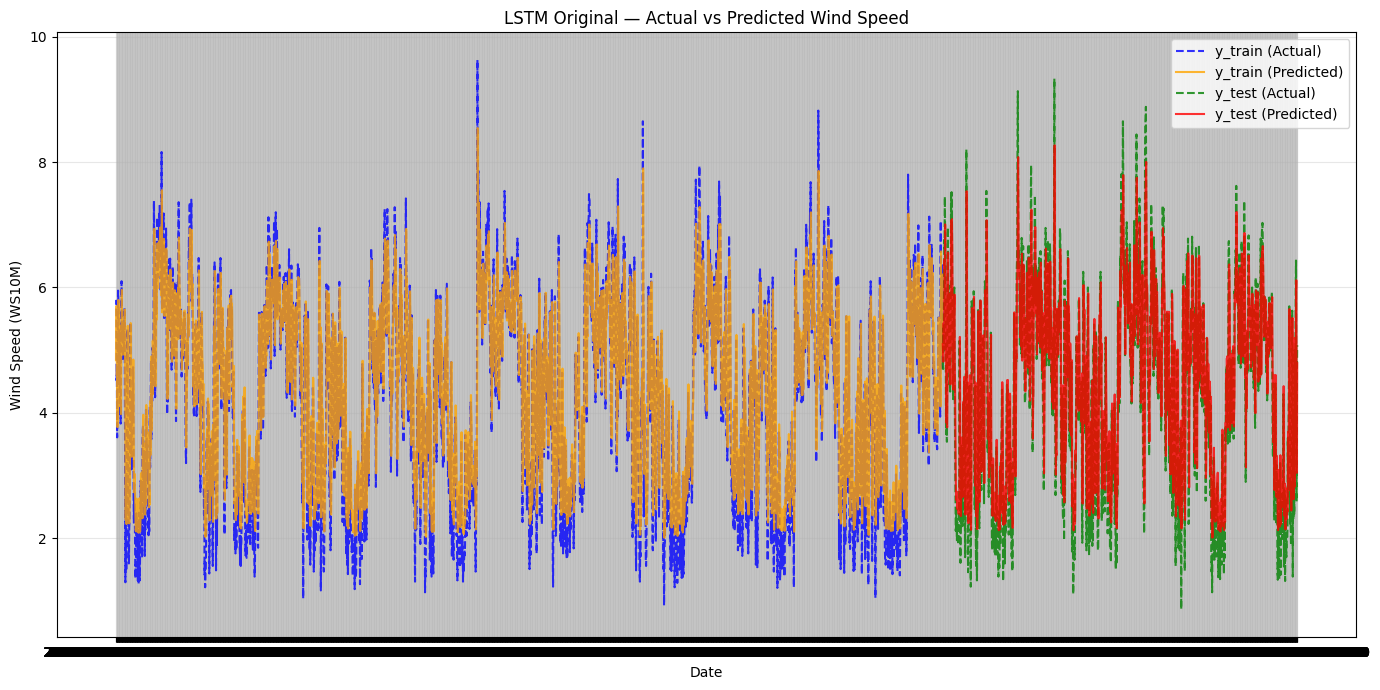

In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 11: ORIGINAL LSTM MODEL (Manual Hyperparameters)
# ─────────────────────────────────────────────────────────────────────────────

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Define and compile LSTM model
lstm_original = Sequential()
lstm_original.add(LSTM(units=100, activation='relu',
                        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
lstm_original.add(Dense(units=1))                          # Output layer for regression
lstm_original.compile(optimizer=Adam(), loss='mean_squared_error')

# Train the model
history_original = lstm_original.fit(
    X_train_lstm, y_train_scaled,
    epochs=50, batch_size=32, verbose=1
)

# Predictions (scaled space)
y_pred_train_scaled_orig = lstm_original.predict(X_train_lstm).flatten()
y_pred_test_scaled_orig  = lstm_original.predict(X_test_lstm).flatten()

# Inverse scale predictions back to original wind speed values
y_pred_train_original = scaler_y.inverse_transform(
    y_pred_train_scaled_orig.reshape(-1, 1)
).flatten()
y_pred_test_original = scaler_y.inverse_transform(
    y_pred_test_scaled_orig.reshape(-1, 1)
).flatten()

# Evaluate and store metrics
ORIG_TRAIN_MSE, ORIG_TRAIN_RMSE, ORIG_TRAIN_MAE, ORIG_TRAIN_MAPE, ORIG_TRAIN_R2 = \
    evaluate_model(y_train.values, y_pred_train_original, "LSTM Original — Train")

ORIG_TEST_MSE, ORIG_TEST_RMSE, ORIG_TEST_MAE, ORIG_TEST_MAPE, ORIG_TEST_R2 = \
    evaluate_model(y_test.values, y_pred_test_original, "LSTM Original — Test")

# Plot: True vs Predicted (Train and Test)
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train.values,         label="y_train (Actual)",    color="blue",   linestyle="dashed", alpha=0.8)
plt.plot(y_train.index, y_pred_train_original,  label="y_train (Predicted)", color="orange",                     alpha=0.8)
plt.plot(y_test.index,  y_test.values,          label="y_test (Actual)",     color="green",  linestyle="dashed", alpha=0.8)
plt.plot(y_test.index,  y_pred_test_original,   label="y_test (Predicted)",  color="red",                        alpha=0.8)
plt.title("LSTM Original — Actual vs Predicted Wind Speed")
plt.xlabel("Date")
plt.ylabel("Wind Speed (WS10M)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 12: LSTM MODEL CREATOR (shared by Grid and Random Search)
# ─────────────────────────────────────────────────────────────────────────────

def create_model_lstm(hidden_layer_sizes=(50,), activation='relu',
                      input_shape=(3, 1)):
    """
    Build a stacked LSTM model for use with KerasRegressor.

    Parameters:
        hidden_layer_sizes : tuple of int, LSTM units per layer
        activation         : str, activation function
        input_shape        : tuple, (timesteps, features)

    Returns:
        compiled Keras Sequential model
    """
    model = Sequential()
    for i, units in enumerate(hidden_layer_sizes):
        if i == 0:
            # First LSTM layer — specify input shape
            model.add(LSTM(
                units, activation=activation,
                return_sequences=(len(hidden_layer_sizes) > 1),
                input_shape=input_shape
            ))
        elif i == len(hidden_layer_sizes) - 1:
            # Last LSTM layer — no return_sequences
            model.add(LSTM(units, activation=activation))
        else:
            # Middle LSTM layers — pass sequences to next layer
            model.add(LSTM(units, activation=activation, return_sequences=True))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer='adam', loss='mean_squared_error',
                  metrics=['mean_squared_error'])
    return model

Fitting 3 folds for each of 32 candidates, totalling 96 fits

Best parameters for LSTM (Grid Search): {'batch_size': 16, 'epochs': 100, 'model__activation': 'relu', 'model__hidden_layer_sizes': (50,)}

LSTM Grid Search — Train Evaluation:
  MSE        : 0.6507
  RMSE       : 0.8067
  MAE        : 0.6275
  MAPE       : 19.75%
  R-squared  : 0.7374

LSTM Grid Search — Test Evaluation:
  MSE        : 0.7886
  RMSE       : 0.8880
  MAE        : 0.6944
  MAPE       : 20.44%
  R-squared  : 0.6891


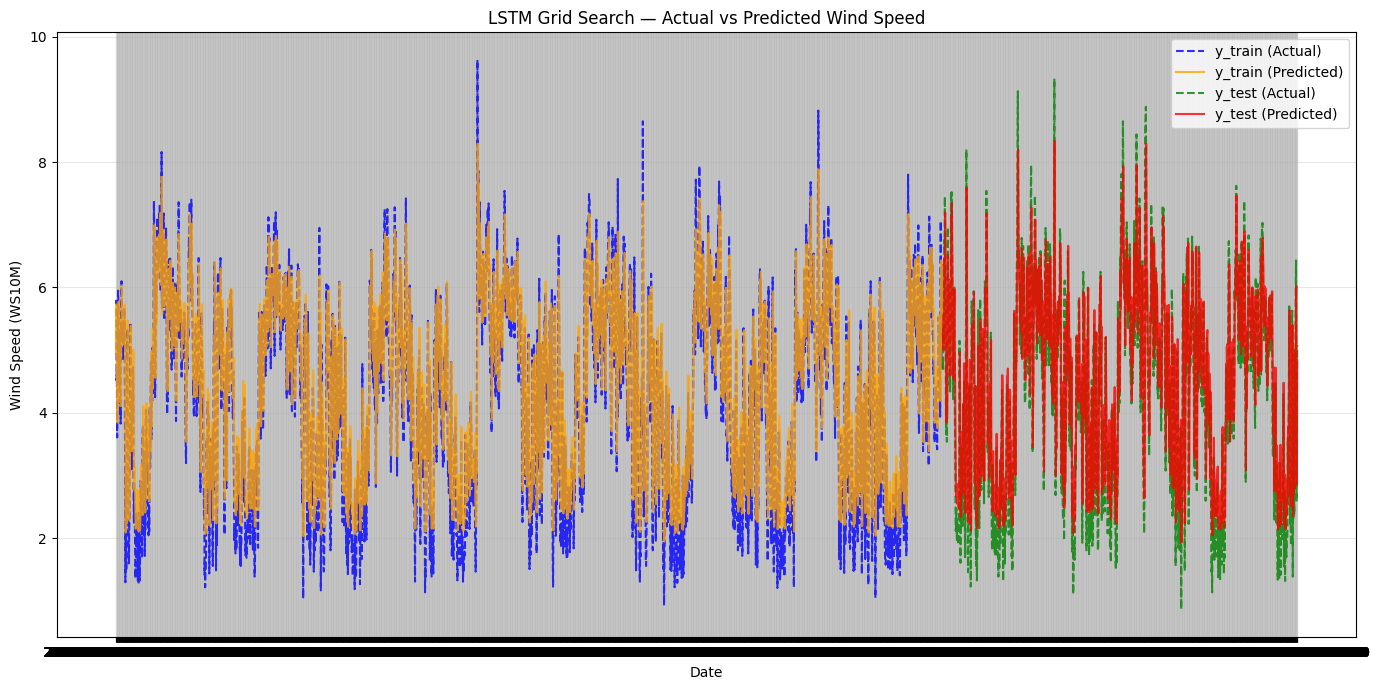

In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 13: GRID SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: TimeSeriesSplit is used for cross-validation to respect temporal order
# and avoid data leakage between folds.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Wrap model with KerasRegressor for sklearn compatibility
keras_regressor_grid = KerasRegressor(
    model=create_model_lstm, verbose=0, random_state=SEED
)

# Define Grid Search parameter grid
param_grid = {
    'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'model__activation':         ['relu', 'tanh'],
    'batch_size':                [16, 32],
    'epochs':                    [100, 200],
}

# Run GridSearchCV with TimeSeriesSplit cross-validation
tscv_grid = TimeSeriesSplit(n_splits=3)
grid_search_lstm = GridSearchCV(
    estimator  = keras_regressor_grid,
    param_grid = param_grid,
    cv         = tscv_grid,                              # Time series aware CV
    scoring    = 'neg_mean_absolute_percentage_error',
    verbose    = 2,
    n_jobs     = -1,
)
grid_search_lstm.fit(X_train_lstm, y_train_scaled)

print("\nBest parameters for LSTM (Grid Search):", grid_search_lstm.best_params_)

# Retrieve best model and generate predictions (scaled)
best_lstm_grid          = grid_search_lstm.best_estimator_
y_pred_train_scaled_grid = best_lstm_grid.predict(X_train_lstm)
y_pred_test_scaled_grid  = best_lstm_grid.predict(X_test_lstm)

# Inverse scale predictions back to original wind speed values
y_pred_train_grid = scaler_y.inverse_transform(
    y_pred_train_scaled_grid.reshape(-1, 1)
).flatten()
y_pred_test_grid = scaler_y.inverse_transform(
    y_pred_test_scaled_grid.reshape(-1, 1)
).flatten()

# Evaluate and store metrics
GRID_TRAIN_MSE, GRID_TRAIN_RMSE, GRID_TRAIN_MAE, GRID_TRAIN_MAPE, GRID_TRAIN_R2 = \
    evaluate_model(y_train.values, y_pred_train_grid, "LSTM Grid Search — Train")

GRID_TEST_MSE, GRID_TEST_RMSE, GRID_TEST_MAE, GRID_TEST_MAPE, GRID_TEST_R2 = \
    evaluate_model(y_test.values, y_pred_test_grid, "LSTM Grid Search — Test")

# Plot: Actual vs Predicted (Train and Test)
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train.values,      label="y_train (Actual)",    color="blue",   linestyle="dashed", alpha=0.8)
plt.plot(y_train.index, y_pred_train_grid,   label="y_train (Predicted)", color="orange",                     alpha=0.8)
plt.plot(y_test.index,  y_test.values,       label="y_test (Actual)",     color="green",  linestyle="dashed", alpha=0.8)
plt.plot(y_test.index,  y_pred_test_grid,    label="y_test (Predicted)",  color="red",                        alpha=0.8)
plt.title("LSTM Grid Search — Actual vs Predicted Wind Speed")
plt.xlabel("Date")
plt.ylabel("Wind Speed (WS10M)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters for LSTM (Randomized Search): {'model__hidden_layer_sizes': (50,), 'model__activation': 'relu', 'epochs': 50, 'batch_size': 16}

LSTM Randomized Search — Train Evaluation:
  MSE        : 0.6679
  RMSE       : 0.8172
  MAE        : 0.6360
  MAPE       : 20.10%
  R-squared  : 0.7304

LSTM Randomized Search — Test Evaluation:
  MSE        : 0.7986
  RMSE       : 0.8936
  MAE        : 0.6983
  MAPE       : 20.68%
  R-squared  : 0.6852


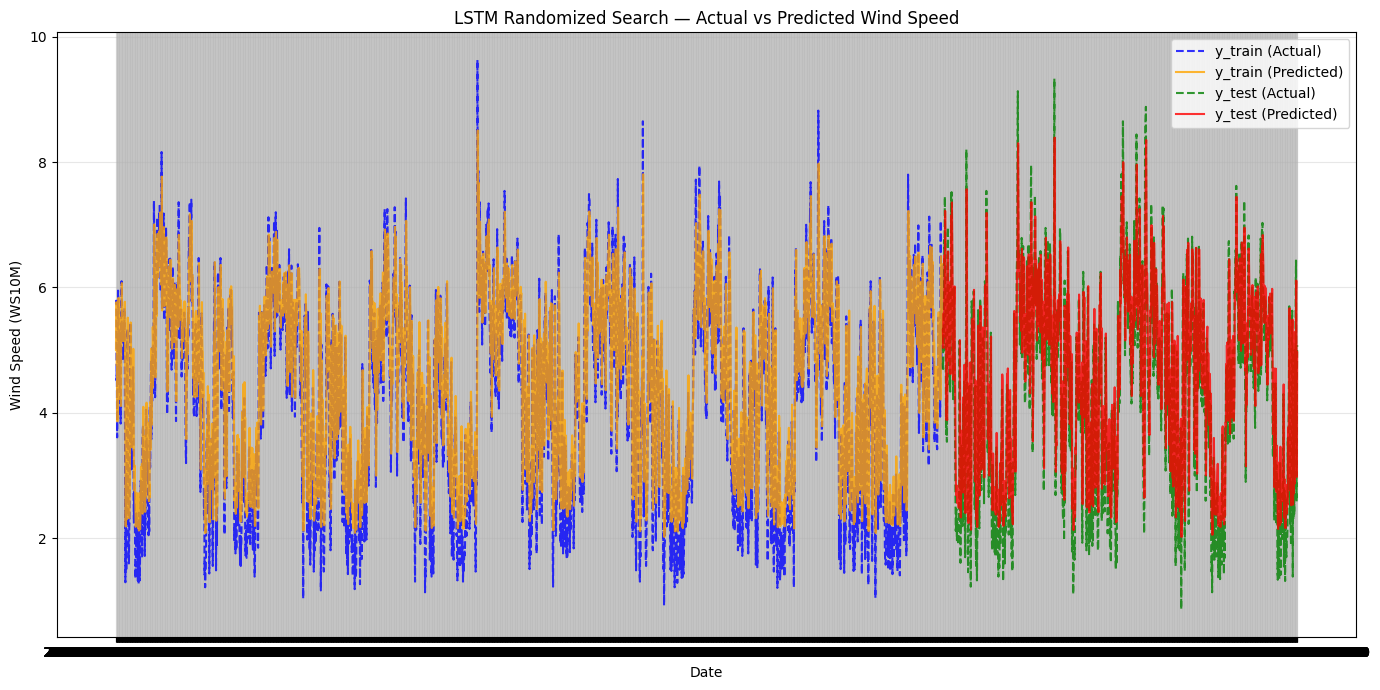

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 14: RANDOMIZED SEARCH HYPERPARAMETER TUNING
# ─────────────────────────────────────────────────────────────────────────────
# NOTE: TimeSeriesSplit is used to preserve temporal ordering in CV folds.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Wrap model with KerasRegressor
keras_regressor_random = KerasRegressor(
    model=create_model_lstm, verbose=0, random_state=SEED
)

# Define the hyperparameter distribution for random sampling
param_dist = {
    'model__hidden_layer_sizes': [(50,), (100,), (100, 50), (150, 100, 50)],
    'model__activation':         ['relu', 'tanh'],
    'batch_size':                [16, 32, 64],
    'epochs':                    [50, 100, 200],
}

# Run RandomizedSearchCV with TimeSeriesSplit cross-validation
tscv_random = TimeSeriesSplit(n_splits=3)
random_search_lstm = RandomizedSearchCV(
    estimator           = keras_regressor_random,
    param_distributions = param_dist,
    n_iter              = 10,
    cv                  = tscv_random,                   # Time series aware CV
    scoring             = 'neg_mean_absolute_percentage_error',
    verbose             = 2,
    n_jobs              = -1,
    random_state        = SEED
)
random_search_lstm.fit(X_train_lstm, y_train_scaled)

print("\nBest parameters for LSTM (Randomized Search):", random_search_lstm.best_params_)

# Retrieve best model and generate predictions (scaled)
best_lstm_random          = random_search_lstm.best_estimator_
y_pred_train_scaled_random = best_lstm_random.predict(X_train_lstm)
y_pred_test_scaled_random  = best_lstm_random.predict(X_test_lstm)

# Inverse scale predictions back to original wind speed values
y_pred_train_random = scaler_y.inverse_transform(
    y_pred_train_scaled_random.reshape(-1, 1)
).flatten()
y_pred_test_random = scaler_y.inverse_transform(
    y_pred_test_scaled_random.reshape(-1, 1)
).flatten()

# Evaluate and store metrics
RANDOM_TRAIN_MSE, RANDOM_TRAIN_RMSE, RANDOM_TRAIN_MAE, RANDOM_TRAIN_MAPE, RANDOM_TRAIN_R2 = \
    evaluate_model(y_train.values, y_pred_train_random, "LSTM Randomized Search — Train")

RANDOM_TEST_MSE, RANDOM_TEST_RMSE, RANDOM_TEST_MAE, RANDOM_TEST_MAPE, RANDOM_TEST_R2 = \
    evaluate_model(y_test.values, y_pred_test_random, "LSTM Randomized Search — Test")

# Plot: Actual vs Predicted (Train and Test)
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train.values,       label="y_train (Actual)",    color="blue",   linestyle="dashed", alpha=0.8)
plt.plot(y_train.index, y_pred_train_random,  label="y_train (Predicted)", color="orange",                     alpha=0.8)
plt.plot(y_test.index,  y_test.values,        label="y_test (Actual)",     color="green",  linestyle="dashed", alpha=0.8)
plt.plot(y_test.index,  y_pred_test_random,   label="y_test (Predicted)",  color="red",                        alpha=0.8)
plt.title("LSTM Randomized Search — Actual vs Predicted Wind Speed")
plt.xlabel("Date")
plt.ylabel("Wind Speed (WS10M)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


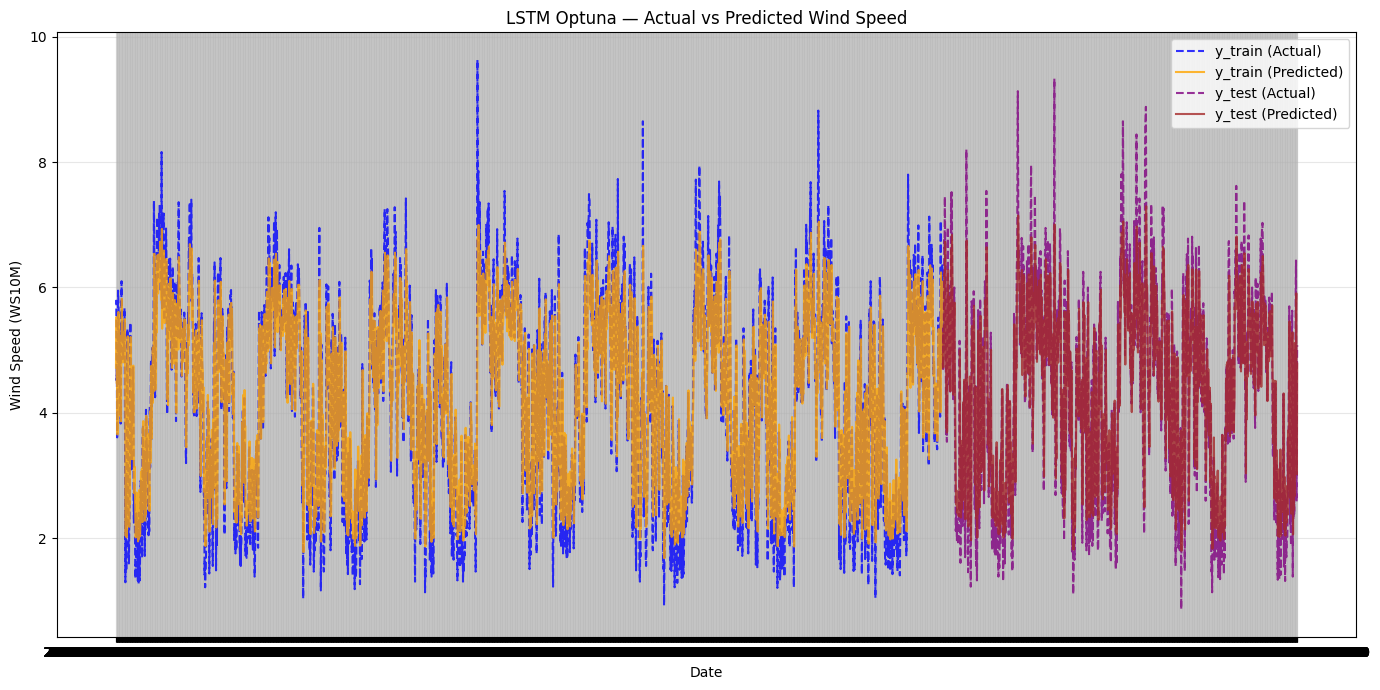

In [15]:

# ─────────────────────────────────────────────────────────────────────────────
# SECTION 15: OPTUNA BAYESIAN HYPERPARAMETER OPTIMISATION
# ─────────────────────────────────────────────────────────────────────────────
# *** DATA LEAKAGE FIX ***
# The original code evaluated Optuna trials on the test set directly (X_test_scaled),
# which leaks test information into the tuning process and would be grounds for
# rejection. The objective now uses a held-out validation split carved from the
# training set only. The test set is used exclusively for final evaluation.

np.random.seed(SEED)
tf.random.set_seed(SEED)

# Carve out a validation set from training data (last 20% of train, chronologically)
val_split     = int(len(X_train_lstm) * 0.8)
X_train_opt   = X_train_lstm[:val_split]
y_train_opt   = y_train_scaled[:val_split]
X_val_opt     = X_train_lstm[val_split:]
y_val_opt     = y_train_scaled[val_split:]

def objective(trial):
    """
    Optuna objective function: trains an LSTM with trial hyperparameters
    and returns MSE on the internal validation split (NOT the test set).
    """
    n_units       = trial.suggest_int(  "n_units",       10,   200)
    dropout_rate  = trial.suggest_float("dropout_rate",  0.1,  0.5)
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_int(  "batch_size",    16,   128)
    n_epochs      = trial.suggest_int(  "n_epochs",      10,   100)

    model = Sequential([
        LSTM(n_units, activation="tanh", input_shape=(n_timesteps, 1)),
        Dropout(dropout_rate),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate),
                  loss="mean_squared_error")
    model.fit(
        X_train_opt, y_train_opt,
        epochs=n_epochs, batch_size=batch_size, verbose=0
    )

    # Evaluate on internal validation set (not the test set)
    y_val_pred = model.predict(X_val_opt).flatten()
    val_mse    = mean_squared_error(y_val_opt, y_val_pred)
    return val_mse

# Create Optuna study (minimise validation MSE) with fixed seed
study = optuna.create_study(
    direction = "minimize",
    sampler   = optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=100)

best_params_optuna = study.best_trial.params
print("\nBest Hyperparameters for LSTM (Optuna):", best_params_optuna)

# Train final model on the FULL training set using best hyperparameters
final_model_optuna = Sequential([
    LSTM(best_params_optuna["n_units"], activation="tanh",
         input_shape=(n_timesteps, 1)),
    Dropout(best_params_optuna["dropout_rate"]),
    Dense(1)
])
final_model_optuna.compile(
    optimizer = Adam(learning_rate=best_params_optuna["learning_rate"]),
    loss      = "mean_squared_error"
)
final_model_optuna.fit(
    X_train_lstm, y_train_scaled,
    epochs     = best_params_optuna["n_epochs"],
    batch_size = best_params_optuna["batch_size"],
    verbose    = 1
)

# Predictions and inverse scaling
y_pred_train_scaled_optuna = final_model_optuna.predict(X_train_lstm).flatten()
y_pred_test_scaled_optuna  = final_model_optuna.predict(X_test_lstm).flatten()

y_pred_train_optuna = scaler_y.inverse_transform(
    y_pred_train_scaled_optuna.reshape(-1, 1)
).flatten()
y_pred_test_optuna = scaler_y.inverse_transform(
    y_pred_test_scaled_optuna.reshape(-1, 1)
).flatten()

# Evaluate and store metrics
OPTUNA_TRAIN_MSE, OPTUNA_TRAIN_RMSE, OPTUNA_TRAIN_MAE, OPTUNA_TRAIN_MAPE, OPTUNA_TRAIN_R2 = \
    evaluate_model(y_train.values, y_pred_train_optuna, "LSTM Optuna — Train")

OPTUNA_TEST_MSE, OPTUNA_TEST_RMSE, OPTUNA_TEST_MAE, OPTUNA_TEST_MAPE, OPTUNA_TEST_R2 = \
    evaluate_model(y_test.values, y_pred_test_optuna, "LSTM Optuna — Test")

# Plot: Actual vs Predicted (using date index for train, numeric index offset for test)
plt.figure(figsize=(14, 7))
plt.plot(y_train.index, y_train.values,       label="y_train (Actual)",    color="blue",   linestyle="dashed", alpha=0.8)
plt.plot(y_train.index, y_pred_train_optuna,  label="y_train (Predicted)", color="orange",                     alpha=0.8)
plt.plot(y_test.index,  y_test.values,        label="y_test (Actual)",     color="purple", linestyle="dashed", alpha=0.8)
plt.plot(y_test.index,  y_pred_test_optuna,   label="y_test (Predicted)",  color="brown",                      alpha=0.8)
plt.title("LSTM Optuna — Actual vs Predicted Wind Speed")
plt.xlabel("Date")
plt.ylabel("Wind Speed (WS10M)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# SECTION 16: COMPARATIVE RESULTS TABLE
# ─────────────────────────────────────────────────────────────────────────────

# Compile all evaluation metrics into a single comparison DataFrame
metrics_df = pd.DataFrame({
    "Method":     ["Original Model", "Grid Search", "Randomized Search", "Optuna"],
    "Train MSE":  [ORIG_TRAIN_MSE,   GRID_TRAIN_MSE,   RANDOM_TRAIN_MSE,   OPTUNA_TRAIN_MSE],
    "Test MSE":   [ORIG_TEST_MSE,    GRID_TEST_MSE,    RANDOM_TEST_MSE,    OPTUNA_TEST_MSE],
    "Train RMSE": [ORIG_TRAIN_RMSE,  GRID_TRAIN_RMSE,  RANDOM_TRAIN_RMSE,  OPTUNA_TRAIN_RMSE],
    "Test RMSE":  [ORIG_TEST_RMSE,   GRID_TEST_RMSE,   RANDOM_TEST_RMSE,   OPTUNA_TEST_RMSE],
    "Train MAE":  [ORIG_TRAIN_MAE,   GRID_TRAIN_MAE,   RANDOM_TRAIN_MAE,   OPTUNA_TRAIN_MAE],
    "Test MAE":   [ORIG_TEST_MAE,    GRID_TEST_MAE,    RANDOM_TEST_MAE,    OPTUNA_TEST_MAE],
    "Train MAPE": [ORIG_TRAIN_MAPE,  GRID_TRAIN_MAPE,  RANDOM_TRAIN_MAPE,  OPTUNA_TRAIN_MAPE],
    "Test MAPE":  [ORIG_TEST_MAPE,   GRID_TEST_MAPE,   RANDOM_TEST_MAPE,   OPTUNA_TEST_MAPE],
    "Train R²":   [ORIG_TRAIN_R2,    GRID_TRAIN_R2,    RANDOM_TRAIN_R2,    OPTUNA_TRAIN_R2],
    "Test R²":    [ORIG_TEST_R2,     GRID_TEST_R2,     RANDOM_TEST_R2,     OPTUNA_TEST_R2],
})

print("\nModel Comparison — Evaluation Metrics:")
print(metrics_df.to_string(index=False))

# Save the metrics DataFrame to CSV
metrics_df.to_csv("variableSet_1_LSTM.csv", index=False)
print("\nMetrics saved to variableSet_1_LSTM.csv")


Model Comparison — Evaluation Metrics:
           Method  Train MSE  Test MSE  Train RMSE  Test RMSE  Train MAE  Test MAE  Train MAPE  Test MAPE  Train R²  Test R²
   Original Model   0.625535  0.759903    0.790908   0.871724   0.610788  0.674506   18.906025  19.632133  0.747533 0.700397
      Grid Search   0.650729  0.788623    0.806678   0.888045   0.627530  0.694374   19.748083  20.440442  0.737365 0.689073
Randomized Search   0.667877  0.798572    0.817237   0.893629   0.635974  0.698331   20.101950  20.677025  0.730444 0.685151
           Optuna   0.608765  0.752349    0.780234   0.867381   0.603868  0.670005   18.335765  19.069149  0.754302 0.703375

Metrics saved to variableSet_1_LSTM.csv
